# Power Dependence Analysis - MEOP Polarization Data

This notebook analyzes polarization relaxation data from power dependence tests using ROOT/PyROOT for fitting.

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
import numpy as np
import ROOT
from array import array
import math
import os
from pathlib import Path

## Load Data

Load Excel files from the Power Dependence Tests directory and extract metadata from filenames.

In [9]:
# Directory containing all the data files
data_dir = "/Users/snip/Documents/MEOP/Power Dependence Tests"
output_dir = "/Users/snip/Documents/MEOP/power_dependence_plots"

# Create output directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# Get all Excel files in the directory
excel_files = list(Path(data_dir).glob("*.xlsx"))
print(f"Found {len(excel_files)} Excel files to process\n")

# Process first file : Loop could be done here to process all files
file_path = str(excel_files[1])
print(f"Processing: {file_path}")

# Extract metadata from filename (e.g., "3W_C8_datagrab1.xlsx")
filename = Path(file_path).stem
parts = filename.split("_")
power = parts[0]  # e.g., "3W"
cell = parts[1]   # e.g., "C8"
datagrab = parts[2]  # e.g., "datagrab1"

print(f"Power: {power}, Cell: {cell}, Datagrab: {datagrab}")

# Read the Excel file
df = pd.read_excel(file_path)

# Drop and rename columns
df.drop(columns=["Time - Voltage (Formula Result)","Polarization (%) - Voltage (Formula Result)"], inplace=True)
df.rename(columns={"Time - Voltage (Formula Result).1":"time","Polarization (%) - Voltage (Formula Result).1":"polarization"}, inplace=True)

Found 37 Excel files to process

Processing: /Users/snip/Documents/MEOP/Power Dependence Tests/3W_C9_datagrab1.xlsx
Power: 3W, Cell: C9, Datagrab: datagrab1


## Time Conversion and Rollover Detection

Convert MM:SS time format to seconds and detect time rollovers (when time resets from 59:59 to 00:00).

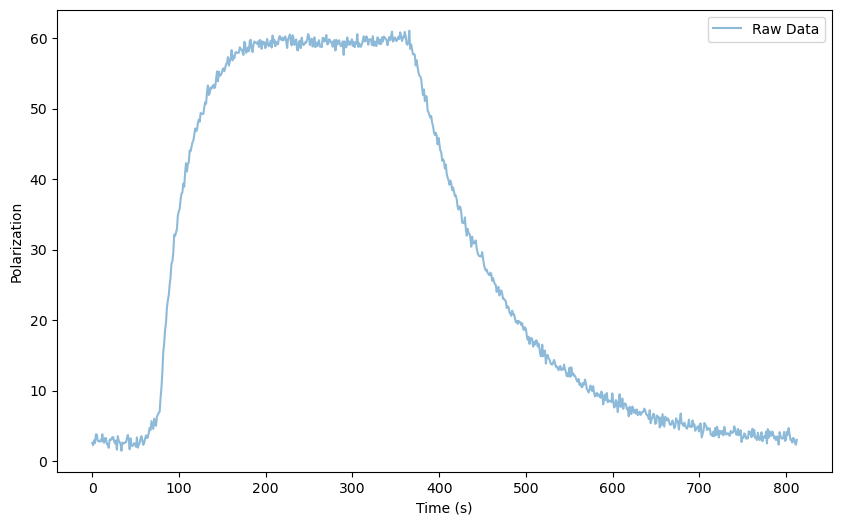

In [10]:
# Convert time string to seconds
def time_to_seconds(time_str):
    parts = str(time_str).split(':')
    if len(parts) == 2:  # MM:SS format
        return int(parts[0]) * 60 + float(parts[1])
    elif len(parts) == 3:  # HH:MM:SS format
        return int(parts[0]) * 3600 + int(parts[1]) * 60 + float(parts[2])
    else:
        return float(time_str)  # Already in seconds

# Convert all times to seconds
time_seconds = df["time"].apply(time_to_seconds).values

# Detect and fix rollovers
corrected_time = [time_seconds[0]]
cumulative_offset = 0

for i in range(1, len(time_seconds)):
    if time_seconds[i] < time_seconds[i-1] - 10:  # Rollover detected
        cumulative_offset += 3600
        print(f"Detected time rollover at index {i}: {time_seconds[i-1]:.1f}s -> {time_seconds[i]:.1f}s (adding {cumulative_offset}s offset)")
    corrected_time.append(time_seconds[i] + cumulative_offset)

df["time"] = corrected_time
df["time"] = df["time"] - df["time"].min()  # Start from zero

# Plot raw data
plt.figure(figsize=(10,6))
plt.plot(df["time"], df["polarization"], label="Raw Data", alpha=0.5)
plt.legend()
plt.xlabel("Time (s)")
plt.ylabel("Polarization")
plt.show()

## Data Smoothing and Relaxation Time Detection

Apply Savitzky-Golay filter and detect decay start point using derivative analysis.

In [11]:
df["smoothed"] = savgol_filter(df["polarization"], 30, 3)
df["derivative"] = np.gradient(df["smoothed"])

# Find global max
global_max_index = df["smoothed"].idxmax()

# Look for where decay consistently starts
decay_start_index = global_max_index
global_max_pol = df["smoothed"][global_max_index]
threshold_10_percent = global_max_pol * 0.9

for i in range(global_max_index, len(df)):
    if i + 5 < len(df):
        if all(df["derivative"].iloc[i:i+5] < 0) and df["smoothed"].iloc[i] <= threshold_10_percent:
            decay_start_index = i
            break

max_index = decay_start_index - 12
max_pol = df["smoothed"][max_index]
min_index = df["smoothed"].idxmin()
min_pol = df["smoothed"][min_index]

print(f"Max index: {max_index}, Min index: {min_index}")

target_value = max_pol / np.e 
print(f"Target value for relaxation: {target_value:.2f}%")

relaxation_data = df.iloc[max_index:min_index+1]
relaxation_data_full = relaxation_data.copy()

relaxation_data = relaxation_data[relaxation_data["smoothed"] > target_value]
relaxation_data_full = relaxation_data_full[relaxation_data_full["smoothed"] > min_pol]
max_time = df["time"][max_index]

if len(relaxation_data) == 0:
    print(f"⚠ Warning: No data points above target value (1/e point)")
    print(f"Using full decay range for analysis")
    relaxation_data = relaxation_data_full
    if len(relaxation_data) < 2:
        print(f"Error: Insufficient data points for relaxation analysis")
        relaxation_time = 0
    else:
        relaxation_time = relaxation_data["time"].iloc[-1] - max_time
else:
    relaxation_time = relaxation_data["time"].iloc[-1] - max_time

print(f"Global max index: {global_max_index}, Decay start index: {decay_start_index}, Selected max index: {max_index}")
print(f"Max polarization (before decay): {max_pol:.2f}%")
print(f"Relaxation time: {relaxation_time:.3f} seconds")

Max index: 348, Min index: 774
Target value for relaxation: 21.78%
Global max index: 338, Decay start index: 360, Selected max index: 348
Max polarization (before decay): 59.19%
Relaxation time: 113.324 seconds


AUTOMATIC PHASE DETECTION
Detected transitions:
  Buildup starts at:  t ≈ 65.1s (index 62)
  Plateau starts at:  t ≈ 172.2s (index 164)
  Decay starts at:    t ≈ 359.2s (index 342)

OPTIMIZED FIT RANGES
  1. Initial constant:  [0.0, 75.1] s
  2. Buildup:           [87.1, 150.2] s
  3. Plateau constant:  [155.2, 379.2] s
  4. Decay:             [375.2, 812.2] s


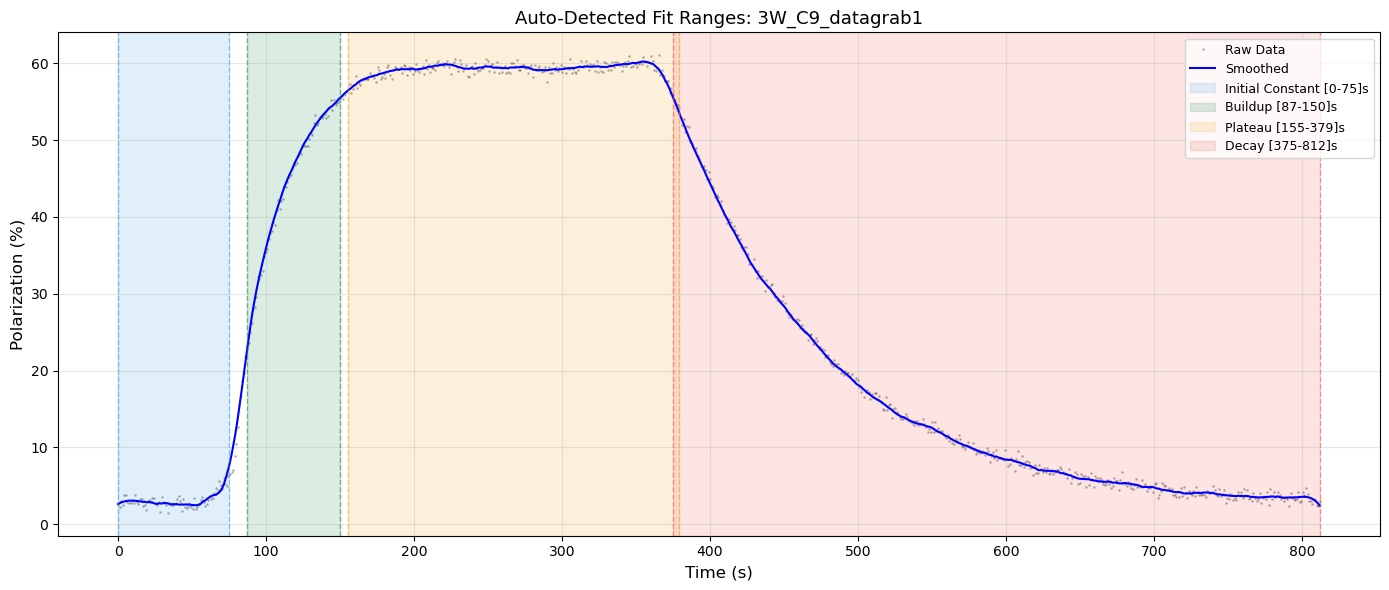

In [12]:
def compute_fit_ranges(df, verbose=True):
    """
    Automatically compute fit ranges for the four-phase polarization data.
    
    Phase sequence: Initial Constant → Buildup → Plateau → Decay
    
    Algorithm:
    1. Use smoothed derivative to detect phase transitions
    2. Find buildup start: first sustained large positive derivative
    3. Find plateau start: derivative returns near zero after buildup peak
    4. Find decay start: first sustained large negative derivative after plateau
    5. Optimize each boundary using chi2/NDF scanning
    
    Returns dict with all 8 range boundaries.
    """
    time = df["time"].values
    pol_smooth = df["smoothed"].values
    deriv = df["derivative"].values
    
    t_min = time[0]
    t_max = time[-1]
    
    # --- Step 1: Compute a heavily smoothed derivative for robust transition detection ---
    # Use a rolling window on the derivative to reduce noise
    window = 15  # points for rolling average
    deriv_smooth = np.convolve(deriv, np.ones(window)/window, mode='same')
    
    # Key thresholds based on derivative statistics
    deriv_max = np.max(deriv_smooth)
    deriv_min = np.min(deriv_smooth)
    
    # Threshold for "significant" positive/negative derivative
    pos_threshold = deriv_max * 0.15  # 15% of peak positive derivative
    neg_threshold = deriv_min * 0.15  # 15% of peak negative derivative
    
    # Near-zero threshold for plateau detection
    zero_threshold = max(abs(deriv_max), abs(deriv_min)) * 0.05
    
    # --- Step 2: Find buildup start ---
    # First time derivative exceeds positive threshold for several consecutive points
    buildup_start_idx = 0
    consecutive_needed = 5
    for i in range(len(deriv_smooth) - consecutive_needed):
        if all(deriv_smooth[i:i+consecutive_needed] > pos_threshold):
            buildup_start_idx = i
            break
    
    # --- Step 3: Find plateau start ---
    # After the derivative peak, find where it drops back to near-zero
    deriv_peak_idx = np.argmax(deriv_smooth)
    
    plateau_start_idx = deriv_peak_idx
    for i in range(deriv_peak_idx, len(deriv_smooth) - consecutive_needed):
        if all(abs(deriv_smooth[i:i+consecutive_needed]) < zero_threshold):
            plateau_start_idx = i
            break
    
    # --- Step 4: Find decay start ---
    # After plateau, find where derivative becomes consistently negative
    decay_start_idx = plateau_start_idx
    for i in range(plateau_start_idx, len(deriv_smooth) - consecutive_needed):
        if all(deriv_smooth[i:i+consecutive_needed] < neg_threshold):
            decay_start_idx = i
            break
    
    # Convert indices to times
    t_buildup_start = time[buildup_start_idx]
    t_plateau_start = time[plateau_start_idx]
    t_decay_start = time[decay_start_idx]
    
    if verbose:
        print("="*70)
        print("AUTOMATIC PHASE DETECTION")
        print("="*70)
        print(f"Detected transitions:")
        print(f"  Buildup starts at:  t ≈ {t_buildup_start:.1f}s (index {buildup_start_idx})")
        print(f"  Plateau starts at:  t ≈ {t_plateau_start:.1f}s (index {plateau_start_idx})")
        print(f"  Decay starts at:    t ≈ {t_decay_start:.1f}s (index {decay_start_idx})")
    
    # --- Step 5: Chi2/NDF optimization of boundaries ---
    # For each boundary, scan a window and find the value that gives best chi2/NDF
    
    def try_constant_fit(t_data, p_data, t_lo, t_hi):
        """Fit constant in [t_lo, t_hi] and return chi2/ndf (or inf if bad)"""
        mask = (t_data >= t_lo) & (t_data <= t_hi)
        p_sel = p_data[mask]
        if len(p_sel) < 3:
            return np.inf
        mean_val = np.mean(p_sel)
        residuals = p_sel - mean_val
        chi2 = np.sum(residuals**2)
        ndf = len(p_sel) - 1
        if ndf <= 0:
            return np.inf
        return chi2 / ndf
    
    def try_exp_fit_quality(t_data, p_data, t_lo, t_hi, fit_type="buildup"):
        """Quick quality metric for exponential fit region using residual variance"""
        mask = (t_data >= t_lo) & (t_data <= t_hi)
        t_sel = t_data[mask]
        p_sel = p_data[mask]
        if len(p_sel) < 5:
            return np.inf
        
        if fit_type == "buildup":
            # For buildup: data should be monotonically increasing
            # Good range = low residual from a smooth trend
            from scipy.optimize import curve_fit
            try:
                def buildup_func(t, a, b, tau):
                    return a - b * np.exp(-(t - t_sel[0]) / tau)
                p0 = [p_sel[-1], p_sel[-1] - p_sel[0], (t_sel[-1] - t_sel[0]) / 3]
                popt, _ = curve_fit(buildup_func, t_sel, p_sel, p0=p0, maxfev=2000)
                residuals = p_sel - buildup_func(t_sel, *popt)
                return np.sum(residuals**2) / (len(p_sel) - 3)
            except:
                return np.inf
        else:
            # For decay: data should be monotonically decreasing
            from scipy.optimize import curve_fit
            try:
                def decay_func(t, a, tau, c):
                    return a * np.exp(-(t - t_sel[0]) / tau) + c
                p0 = [p_sel[0] - p_sel[-1], (t_sel[-1] - t_sel[0]) / 3, p_sel[-1]]
                popt, _ = curve_fit(decay_func, t_sel, p_sel, p0=p0, maxfev=2000)
                residuals = p_sel - decay_func(t_sel, *popt)
                return np.sum(residuals**2) / (len(p_sel) - 3)
            except:
                return np.inf
    
    # --- Optimize initial constant range ---
    # End of initial constant = near buildup start
    # Scan end boundary around detected buildup start
    search_window = 50  # seconds to search around transition
    best_ic_max = t_buildup_start - 10
    best_chi2 = np.inf
    
    for offset in np.arange(-search_window, search_window, 2.0):
        candidate = t_buildup_start + offset
        if candidate <= t_min + 5 or candidate >= t_plateau_start:
            continue
        chi2_val = try_constant_fit(time, pol_smooth, t_min, candidate)
        if abs(chi2_val - 1.0) < abs(best_chi2 - 1.0):  # Closest to chi2/ndf = 1
            best_chi2 = chi2_val
            best_ic_max = candidate
    
    initial_constant_range_min = t_min
    initial_constant_range_max = best_ic_max
    
    # --- Optimize buildup range ---
    # Start: near detected buildup start, End: near plateau start
    best_bu_min = t_buildup_start
    best_bu_max = t_plateau_start
    best_quality = np.inf
    
    for s_off in np.arange(-search_window, search_window/2, 3.0):
        for e_off in np.arange(-search_window/2, search_window, 3.0):
            s_cand = t_buildup_start + s_off
            e_cand = t_plateau_start + e_off
            if s_cand < initial_constant_range_max or e_cand <= s_cand + 30 or e_cand >= t_decay_start:
                continue
            q = try_exp_fit_quality(time, pol_smooth, s_cand, e_cand, "buildup")
            if q < best_quality:
                best_quality = q
                best_bu_min = s_cand
                best_bu_max = e_cand
    
    buildup_range_min = best_bu_min
    buildup_range_max = best_bu_max
    
    # --- Optimize plateau/constant range ---
    # Start: after buildup settles, End: before decay begins
    best_pl_min = t_plateau_start
    best_pl_max = t_decay_start
    best_chi2 = np.inf
    
    for s_off in np.arange(-search_window, search_window/2, 3.0):
        for e_off in np.arange(-search_window/2, search_window, 3.0):
            s_cand = t_plateau_start + s_off
            e_cand = t_decay_start + e_off
            if s_cand < buildup_range_min or e_cand <= s_cand + 20 or e_cand > t_max:
                continue
            chi2_val = try_constant_fit(time, pol_smooth, s_cand, e_cand)
            if abs(chi2_val - 1.0) < abs(best_chi2 - 1.0):
                best_chi2 = chi2_val
                best_pl_min = s_cand
                best_pl_max = e_cand
    
    constant_range_min = best_pl_min
    constant_range_max = best_pl_max
    
    # --- Optimize decay range ---
    # Start: near decay start, End: near data end
    best_dc_min = t_decay_start
    best_dc_max = t_max
    best_quality = np.inf
    
    for s_off in np.arange(-search_window, search_window/2, 3.0):
        s_cand = t_decay_start + s_off
        e_cand = t_max  # Always go to end
        if s_cand < constant_range_min or s_cand >= t_max - 30:
            continue
        q = try_exp_fit_quality(time, pol_smooth, s_cand, e_cand, "decay")
        if q < best_quality:
            best_quality = q
            best_dc_min = s_cand
    
    decay_range_min = best_dc_min
    decay_range_max = t_max
    
    # --- Ensure ranges don't exceed data limits ---
    initial_constant_range_min = max(initial_constant_range_min, t_min)
    initial_constant_range_max = min(initial_constant_range_max, t_max)
    buildup_range_min = max(buildup_range_min, t_min)
    buildup_range_max = min(buildup_range_max, t_max)
    constant_range_min = max(constant_range_min, t_min)
    constant_range_max = min(constant_range_max, t_max)
    decay_range_min = max(decay_range_min, t_min)
    decay_range_max = min(decay_range_max, t_max)
    
    ranges = {
        "initial_constant_range_min": round(initial_constant_range_min, 1),
        "initial_constant_range_max": round(initial_constant_range_max, 1),
        "buildup_range_min": round(buildup_range_min, 1),
        "buildup_range_max": round(buildup_range_max, 1),
        "constant_range_min": round(constant_range_min, 1),
        "constant_range_max": round(constant_range_max, 1),
        "decay_range_min": round(decay_range_min, 1),
        "decay_range_max": round(decay_range_max, 1),
    }
    
    if verbose:
        print(f"\n{'='*70}")
        print("OPTIMIZED FIT RANGES")
        print(f"{'='*70}")
        print(f"  1. Initial constant:  [{ranges['initial_constant_range_min']}, {ranges['initial_constant_range_max']}] s")
        print(f"  2. Buildup:           [{ranges['buildup_range_min']}, {ranges['buildup_range_max']}] s")
        print(f"  3. Plateau constant:  [{ranges['constant_range_min']}, {ranges['constant_range_max']}] s")
        print(f"  4. Decay:             [{ranges['decay_range_min']}, {ranges['decay_range_max']}] s")
        print(f"{'='*70}")
        
        # Visualize the detected ranges
        fig, ax = plt.subplots(figsize=(14, 6))
        ax.plot(df["time"], df["polarization"], 'k.', alpha=0.2, markersize=2, label="Raw Data")
        ax.plot(df["time"], df["smoothed"], 'b-', linewidth=1.5, label="Smoothed")
        
        # Shade each phase region
        colors =['#3498db', "#0f803e", '#f39c12', '#e74c3c']
        labels = ['Initial Constant', 'Buildup', 'Plateau', 'Decay']
        range_pairs = [
            (ranges['initial_constant_range_min'], ranges['initial_constant_range_max']),
            (ranges['buildup_range_min'], ranges['buildup_range_max']),
            (ranges['constant_range_min'], ranges['constant_range_max']),
            (ranges['decay_range_min'], ranges['decay_range_max']),
        ]
        
        for (r_min, r_max), color, label in zip(range_pairs, colors, labels):
            ax.axvspan(r_min, r_max, alpha=0.15, color=color, label=f"{label} [{r_min:.0f}-{r_max:.0f}]s")
            ax.axvline(r_min, color=color, linestyle='--', alpha=0.5, linewidth=1)
            ax.axvline(r_max, color=color, linestyle='--', alpha=0.5, linewidth=1)
        
        ax.set_xlabel("Time (s)", fontsize=12)
        ax.set_ylabel("Polarization (%)", fontsize=12)
        ax.set_title(f"Auto-Detected Fit Ranges: {filename}", fontsize=13)
        ax.legend(loc='best', fontsize=9)
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
    
    return ranges

# Run the automatic range detection
auto_ranges = compute_fit_ranges(df, verbose=True)


## Four-Phase ROOT Fitting

Fit the data using ROOT with four distinct phases:
1. Initial constant phase
2. Buildup phase (exponential growth)
3. Plateau constant phase
4. Decay phase (exponential decay)

In [13]:
# Use auto-detected ranges (from compute_fit_ranges) or override manually
# To override: set use_auto_ranges = False and edit values below
use_auto_ranges = True

if use_auto_ranges:
    initial_constant_range_min = auto_ranges['initial_constant_range_min']
    initial_constant_range_max = auto_ranges['initial_constant_range_max']
    buildup_range_min = auto_ranges['buildup_range_min']
    buildup_range_max = auto_ranges['buildup_range_max']
    constant_range_min = auto_ranges['constant_range_min']
    constant_range_max = auto_ranges['constant_range_max']
    decay_range_min = auto_ranges['decay_range_min']
    decay_range_max = auto_ranges['decay_range_max']
else:
    # Manual override values
    initial_constant_range_min = 0.0
    initial_constant_range_max = 102.0
    buildup_range_min = 128.0
    buildup_range_max = 325.0
    constant_range_min = 215.0
    constant_range_max = 470.0
    decay_range_min = 488.0
    decay_range_max = 1069.0

print("="*70)
print("FIT CONFIGURATION")
print("="*70)
print(f"Initial constant fit range: [{initial_constant_range_min}, {initial_constant_range_max}] seconds")
print(f"Buildup fit range:  [{buildup_range_min}, {buildup_range_max}] seconds")
print(f"Constant fit range: [{constant_range_min}, {constant_range_max}] seconds")
print(f"Decay fit range:    [{decay_range_min}, {decay_range_max}] seconds")
print("="*70)

# Prepare full data
time_full = df["time"].values
pol_full = df["polarization"].values

# Auto-compute initial parameter guesses from the data
pol_smooth = df["smoothed"].values
max_pol_val = np.max(pol_smooth)
min_pol_val = np.min(pol_smooth)

# 1. INITIAL CONSTANT FIT
print("\n" + "="*70)
print("1. INITIAL CONSTANT FIT (before buildup)")
print("="*70)

# Auto-estimate: mean of data in initial range
mask_ic = (time_full >= initial_constant_range_min) & (time_full <= initial_constant_range_max)
P_init_const_init = np.mean(pol_full[mask_ic]) if np.sum(mask_ic) > 0 else 5.0

mask_init_constant = (time_full >= initial_constant_range_min) & (time_full <= initial_constant_range_max)
time_init_constant = time_full[mask_init_constant]
pol_init_constant = pol_full[mask_init_constant]

if len(time_init_constant) > 0:
    n_init_constant = len(time_init_constant)
    x_init_constant = array('d', time_init_constant.tolist())
    y_init_constant = array('d', pol_init_constant.tolist())
    graph_init_constant = ROOT.TGraph(n_init_constant, x_init_constant, y_init_constant)
    graph_init_constant.SetMarkerStyle(23)
    graph_init_constant.SetMarkerSize(0.8)
    graph_init_constant.SetMarkerColor(ROOT.kBlue)
    
    fit_init_constant = ROOT.TF1("fit_init_constant", "[0]", initial_constant_range_min, initial_constant_range_max)
    fit_init_constant.SetParameter(0, P_init_const_init)
    result_init_constant = graph_init_constant.Fit(fit_init_constant, "RS")
    
    P_init_const_fit = fit_init_constant.GetParameter(0)
    P_init_const_err = fit_init_constant.GetParError(0)
    
    print(f"P_init_const = {P_init_const_fit:.3f} ± {P_init_const_err:.3f} %")
    print(f"Chi2/NDF = {result_init_constant.Chi2():.2f} / {result_init_constant.Ndf()} = {result_init_constant.Chi2()/result_init_constant.Ndf():.3f}")
else:
    print("⚠ No data in initial constant range!")
    graph_init_constant = None
    fit_init_constant = None

# 2. BUILDUP FIT
print("\n" + "="*70)
print("2. BUILDUP PHASE FIT: P_inf - (P_inf - P_int) * exp(-(t-t0)/tau_b)")
print("="*70)

# Auto-estimate buildup parameters from the data
mask_bu = (time_full >= buildup_range_min) & (time_full <= buildup_range_max)
pol_bu_data = pol_smooth[mask_bu] if np.sum(mask_bu) > 0 else pol_smooth
P_inf_init = np.max(pol_bu_data) * 0.95
P_int_init = pol_bu_data[0] if len(pol_bu_data) > 0 else min_pol_val
P_offset_init = P_int_init * 0.5
tau_b_init = (buildup_range_max - buildup_range_min) / 3.0
t_offset_init = buildup_range_min

mask_buildup = (time_full >= buildup_range_min) & (time_full <= buildup_range_max)
time_buildup = time_full[mask_buildup]
pol_buildup = pol_full[mask_buildup]

if len(time_buildup) > 0:
    n_buildup = len(time_buildup)
    x_buildup = array('d', time_buildup.tolist())
    y_buildup = array('d', pol_buildup.tolist())
    graph_buildup = ROOT.TGraph(n_buildup, x_buildup, y_buildup)
    graph_buildup.SetMarkerStyle(21)
    graph_buildup.SetMarkerSize(0.8)
    graph_buildup.SetMarkerColor(ROOT.kGreen+2)
    
    fit_buildup = ROOT.TF1("fit_buildup", "([0] - ([0] - [1]) * exp(-(x-[3])/[2]))+[4]", buildup_range_min, buildup_range_max)
    fit_buildup.SetParName(0, "P_inf")
    fit_buildup.SetParName(1, "P_int")
    fit_buildup.SetParName(2, "tau_b")
    fit_buildup.SetParName(3, "t_offset")
    fit_buildup.SetParName(4,"P_Offset")
    fit_buildup.SetParameter(0, P_inf_init)
    fit_buildup.SetParameter(1, P_int_init)
    fit_buildup.SetParameter(2, tau_b_init)
    fit_buildup.SetParameter(3, t_offset_init)
    fit_buildup.SetParameter(4, P_offset_init)
    
    result_buildup = graph_buildup.Fit(fit_buildup, "RS")
    covar_fit_build = result_buildup.GetCovarianceMatrix()
    print("Covariance Matrix for Phase Build-up")
    covar_fit_build.Print()
    
    P_inf_fit = fit_buildup.GetParameter(0)
    P_int_fit = fit_buildup.GetParameter(1)
    tau_b_fit = fit_buildup.GetParameter(2)
    t_offset_fit = fit_buildup.GetParameter(3)
    P_offset_fit = fit_buildup.GetParameter(4)
    
    P_inf_err = fit_buildup.GetParError(0)
    P_int_err = fit_buildup.GetParError(1)
    tau_b_err = fit_buildup.GetParError(2)
    t_offset_err = fit_buildup.GetParError(3)
    P_offset_err = fit_buildup.GetParError(4)
    
    print(f"P_inf     = {P_inf_fit:.3f} ± {P_inf_err:.3f} % (plateau)")
    print(f"P_int     = {P_int_fit:.3f} ± {P_int_err:.3f} % (initial)")
    print(f"tau_b     = {tau_b_fit:.3f} ± {tau_b_err:.3f} s (buildup time)")
    print(f"t_offset  = {t_offset_fit:.3f} ± {t_offset_err:.3f} s (time offset)")
    print(f"P_offset  = {P_offset_fit:.3f} ± {P_offset_err:.3f} % (P_offset)")
    print(f"Chi2/NDF  = {result_buildup.Chi2():.2f} / {result_buildup.Ndf()} = {result_buildup.Chi2()/result_buildup.Ndf():.3f}")
else:
    print("No data in buildup range!")
    graph_buildup = None
    fit_buildup = None

# 3. PLATEAU CONSTANT FIT
print("\n" + "="*70)
print("3. PLATEAU CONSTANT FIT")
print("="*70)

# Auto-estimate plateau constant from the data
mask_pl = (time_full >= constant_range_min) & (time_full <= constant_range_max)
P_const_init = np.mean(pol_smooth[mask_pl]) if np.sum(mask_pl) > 0 else max_pol_val

mask_constant = (time_full >= constant_range_min) & (time_full <= constant_range_max)
time_constant = time_full[mask_constant]
pol_constant = pol_full[mask_constant]

if len(time_constant) > 0:
    n_constant = len(time_constant)
    x_constant = array('d', time_constant.tolist())
    y_constant = array('d', pol_constant.tolist())
    graph_constant = ROOT.TGraph(n_constant, x_constant, y_constant)
    graph_constant.SetMarkerStyle(22)
    graph_constant.SetMarkerSize(0.8)
    graph_constant.SetMarkerColor(ROOT.kOrange+7)
    
    fit_constant = ROOT.TF1("fit_plateau_constant", "[0]", constant_range_min, constant_range_max)
    fit_constant.SetParameter(0, P_const_init)
    result_constant = graph_constant.Fit(fit_constant, "RS")
    
    P_const_fit = fit_constant.GetParameter(0)
    P_const_err = fit_constant.GetParError(0)
    
    print(f"P_plateau = {P_const_fit:.3f} ± {P_const_err:.3f} %")
    print(f"Chi2/NDF  = {result_constant.Chi2():.2f} / {result_constant.Ndf()} = {result_constant.Chi2()/result_constant.Ndf():.3f}")
else:
    print("No data in constant range!")
    graph_constant = None
    fit_constant = None

# 4. DECAY FIT
print("\n" + "="*70)
print("4. DECAY FIT")
print("="*70)

# Auto-estimate decay parameters from the data
mask_dc = (time_full >= decay_range_min) & (time_full <= decay_range_max)
pol_dc_data = pol_smooth[mask_dc] if np.sum(mask_dc) > 0 else pol_smooth
P0_init = pol_dc_data[0] if len(pol_dc_data) > 0 else max_pol_val
tau_init = (decay_range_max - decay_range_min) / 3.0
c_init = pol_dc_data[-1] if len(pol_dc_data) > 0 else min_pol_val
t_offset_decay_init = decay_range_min

mask_decay = (time_full >= decay_range_min) & (time_full <= decay_range_max)
time_decay = time_full[mask_decay]
pol_decay = pol_full[mask_decay]

if len(time_decay) > 0:
    n_decay = len(time_decay)
    x_decay = array('d', time_decay.tolist())
    y_decay = array('d', pol_decay.tolist())
    graph_decay = ROOT.TGraph(n_decay, x_decay, y_decay)
    graph_decay.SetMarkerStyle(20)
    graph_decay.SetMarkerSize(0.8)
    graph_decay.SetMarkerColor(ROOT.kRed)
    
    fit_decay = ROOT.TF1("fit_decay", "[0]*exp(-(x-[3])/[1]) + [2]", decay_range_min, decay_range_max)
    fit_decay.SetParName(0, "P0")
    fit_decay.SetParName(1, "tau")
    fit_decay.SetParName(2, "c")
    fit_decay.SetParName(3, "t_offset_decay")
    fit_decay.SetParameter(0, P0_init)
    fit_decay.SetParameter(1, tau_init)
    fit_decay.SetParameter(2, c_init)
    fit_decay.SetParameter(3, t_offset_decay_init)
    
    result_decay = graph_decay.Fit(fit_decay, "RS")
    
    P0_fit = fit_decay.GetParameter(0)
    tau_fit = fit_decay.GetParameter(1)
    c_fit = fit_decay.GetParameter(2)
    t_offset_decay_fit = fit_decay.GetParameter(3)
    
    P0_err = fit_decay.GetParError(0)
    tau_err = fit_decay.GetParError(1)
    c_err = fit_decay.GetParError(2)
    t_offset_decay_err = fit_decay.GetParError(3)
    
    print(f"P0             = {P0_fit:.3f} ± {P0_err:.3f} %")
    print(f"tau            = {tau_fit:.3f} ± {tau_err:.3f} s (decay time)")
    print(f"c              = {c_fit:.3f} ± {c_err:.3f} % (baseline)")
    print(f"t_offset_decay = {t_offset_decay_fit:.3f} ± {t_offset_decay_err:.3f} s (time offset)")
    print(f"Chi2/NDF = {result_decay.Chi2():.2f} / {result_decay.Ndf()} = {result_decay.Chi2()/result_decay.Ndf():.3f}")
else:
    print("No data in decay range!")
    graph_decay = None
    fit_decay = None

print("\n" + "="*70)

FIT CONFIGURATION
Initial constant fit range: [0.0, 75.1] seconds
Buildup fit range:  [87.1, 150.2] seconds
Constant fit range: [155.2, 379.2] seconds
Decay fit range:    [375.2, 812.2] seconds

1. INITIAL CONSTANT FIT (before buildup)
P_init_const = 3.123 ± 0.116 %
Chi2/NDF = 69.06 / 71 = 0.973

2. BUILDUP PHASE FIT: P_inf - (P_inf - P_int) * exp(-(t-t0)/tau_b)
Covariance Matrix for Phase Build-up
P_inf     = 50.688 ± 0.964 % (plateau)
P_int     = 19.285 ± 1.370 % (initial)
tau_b     = 31.408 ± 0.928 s (buildup time)
t_offset  = 92.709 ± 1.371 s (time offset)
P_offset  = 9.671 ± 0.898 % (P_offset)
Chi2/NDF  = 16.30 / 56 = 0.291

3. PLATEAU CONSTANT FIT
P_plateau = 59.121 ± 0.075 %
Chi2/NDF  = 253.52 / 213 = 1.190

4. DECAY FIT
P0             = 54.188 ± 0.907 %
tau            = 102.964 ± 0.479 s (decay time)
c              = 2.428 ± 0.057 % (baseline)
t_offset_decay = 373.719 ± 1.724 s (time offset)
Chi2/NDF = 107.50 / 413 = 0.260

****************************************
Minimizer is 

## Combined Plot with Error Bands

Create a comprehensive visualization showing all four fits with uncertainty bands.

In [14]:
print("Creating combined plot...")
print("="*70)

c_combined = ROOT.TCanvas("c_combined", "Four-Phase Fit", 1200, 800)
c_combined.SetGrid()

# Plot full data
x_full = array('d', time_full.tolist())
y_full = array('d', pol_full.tolist())
graph_full = ROOT.TGraph(len(time_full), x_full, y_full)
graph_full.SetTitle("Four-Phase Fit: Initial Constant + Buildup + Plateau + Decay;Time (s);Polarization (%)")
graph_full.SetMarkerStyle(20)
graph_full.SetMarkerSize(0.5)
graph_full.SetMarkerColor(ROOT.kBlack)
graph_full.Draw("AP")

# Function to create error band
def create_error_band(fit_func, x_min, x_max, fit_result, color, n_points=100):
    """Create TGraphErrors uncertainty band by propagating errors from covariance matrix"""
    x_vals = array('d')
    y_vals = array('d')
    ex_vals = array('d')
    ey_vals = array('d')

    cov_matrix = fit_result.GetCovarianceMatrix()
    n_par = fit_func.GetNpar()
    step = (x_max - x_min) / float(n_points)
    grad = array('d', [0.0] * n_par)
    
    for i in range(n_points + 1):
        x = x_min + i * step
        y = fit_func.Eval(x)
        fit_func.GradientPar(array('d', [x]), grad)
        
        variance = 0.0
        for j in range(n_par):
            for k in range(n_par):
                variance += grad[j] * grad[k] * cov_matrix(j, k)
        
        sigma = math.sqrt(abs(variance))
        x_vals.append(x)
        y_vals.append(y)
        ex_vals.append(0.0)
        ey_vals.append(sigma)

    n = len(x_vals)
    error_band = ROOT.TGraphErrors(n, x_vals, y_vals, ex_vals, ey_vals)
    error_band.SetFillColorAlpha(color, 0.3)
    error_band.SetFillStyle(1001)
    error_band.SetLineWidth(0)
    error_band.SetMarkerSize(0)
    
    return error_band

# Draw fits and error bands
if fit_init_constant:
    error_band_init = create_error_band(fit_init_constant, initial_constant_range_min, 
                                        initial_constant_range_max, result_init_constant, ROOT.kBlue)
    error_band_init.Draw("3 SAME")
    fit_init_constant.SetLineColor(ROOT.kBlue)
    fit_init_constant.SetLineWidth(3)
    fit_init_constant.Draw("SAME")
    
if fit_buildup:
    error_band_buildup = create_error_band(fit_buildup, buildup_range_min, 
                                           buildup_range_max, result_buildup, ROOT.kGreen+2)
    error_band_buildup.Draw("3 SAME")
    fit_buildup.SetLineColor(ROOT.kGreen+2)
    fit_buildup.SetLineWidth(3)
    fit_buildup.Draw("SAME")
    
if fit_constant:
    error_band_constant = create_error_band(fit_constant, constant_range_min, 
                                            constant_range_max, result_constant, ROOT.kOrange+7)
    error_band_constant.Draw("3 SAME")
    fit_constant.SetLineColor(ROOT.kOrange+7)
    fit_constant.SetLineWidth(3)
    fit_constant.Draw("SAME")
    
if fit_decay:
    error_band_decay = create_error_band(fit_decay, decay_range_min, 
                                         decay_range_max, result_decay, ROOT.kRed)
    error_band_decay.Draw("3 SAME")
    fit_decay.SetLineColor(ROOT.kRed)
    fit_decay.SetLineWidth(3)
    fit_decay.Draw("SAME")

# Add legend
legend = ROOT.TLegend(0.15, 0.65, 0.40, 0.88)
legend.SetTextSize(0.023)
legend.AddEntry(graph_full, "Data", "p")
if fit_init_constant:
    legend.AddEntry(fit_init_constant, "Initial Constant Fit", "l")
if fit_buildup:
    legend.AddEntry(fit_buildup, "Buildup Fit", "l")
if fit_constant:
    legend.AddEntry(fit_constant, "Plateau Constant Fit", "l")
if fit_decay:
    legend.AddEntry(fit_decay, "Decay Fit", "l")
legend.Draw()

# Add fit parameters text boxes
text_size = 0.035
font = 42

# Box 1: Initial Constant & Buildup
param_box1 = ROOT.TPaveText(0.52, 0.15, 0.72, 0.65, "NDC")
param_box1.SetFillColor(ROOT.kWhite)
param_box1.SetBorderSize(1)
param_box1.SetTextAlign(12)
param_box1.SetTextSize(text_size)
param_box1.SetTextFont(font)

if fit_init_constant:
    param_box1.AddText("#bf{1. Initial Constant Phase}")
    param_box1.AddText("function: P = constant")
    param_box1.AddText(f"P_{{init}} = {P_init_const_fit:.2f} #pm {P_init_const_err:.2f} %")
    param_box1.AddText(f"#chi^{{2}}/NDF = {result_init_constant.Chi2():.2f}/{result_init_constant.Ndf()}")
    param_box1.AddText(" ")

if fit_buildup:
    param_box1.AddText("#bf{2. Buildup Phase}")
    param_box1.AddText("func: P_{#infty} - (P_{#infty}-P_{int})e^{-(t-t_{0})/#tau_{b}} + P_{Offset}")
    param_box1.AddText(f"P_{{#infty}} = {P_inf_fit:.2f} #pm {P_inf_err:.2f} %")
    param_box1.AddText(f"P_{{int}} = {P_int_fit:.2f} #pm {P_int_err:.2f} %")
    param_box1.AddText(f"#tau_{{b}} = {tau_b_fit:.2f} #pm {tau_b_err:.2f} s")
    param_box1.AddText(f"t_{{0}} = {t_offset_fit:.2f} #pm {t_offset_err:.2f} s")
    param_box1.AddText(f"#chi^{{2}}/NDF = {result_buildup.Chi2():.2f}/{result_buildup.Ndf()}")
    param_box1.AddText(f"P_{{offset}} = {P_offset_fit:.2f} #pm {P_offset_err:.2f} %")

# Box 2: Plateau & Decay
param_box2 = ROOT.TPaveText(0.73, 0.15, 0.93, 0.65, "NDC")
param_box2.SetFillColor(ROOT.kWhite)
param_box2.SetBorderSize(1)
param_box2.SetTextAlign(12)
param_box2.SetTextSize(text_size)
param_box2.SetTextFont(font)

if fit_constant:
    param_box2.AddText("#bf{3. Plateau Constant Phase}")
    param_box2.AddText("function: P = constant")
    param_box2.AddText(f"P_{{plateau}} = {P_const_fit:.2f} #pm {P_const_err:.2f} %")
    param_box2.AddText(f"#chi^{{2}}/NDF = {result_constant.Chi2():.2f}/{result_constant.Ndf()}")
    param_box2.AddText(" ")

if fit_decay:
    param_box2.AddText("#bf{4. Decay Phase}")
    param_box2.AddText("func: P_{0}e^{-(t-t_{0d})/#tau} + c")
    param_box2.AddText(f"P_{{0}} = {P0_fit:.2f} #pm {P0_err:.2f} %")
    param_box2.AddText(f"#tau = {tau_fit:.2f} #pm {tau_err:.2f} s")
    param_box2.AddText(f"c = {c_fit:.2f} #pm {c_err:.2f} %")
    param_box2.AddText(f"t_{{0d}} = {t_offset_decay_fit:.2f} #pm {t_offset_decay_err:.2f} s")
    param_box2.AddText(f"#chi^{{2}}/NDF = {result_decay.Chi2():.2f}/{result_decay.Ndf()}")

param_box1.Draw()
param_box2.Draw()

c_combined.Update()
c_combined.Draw()

# Save plot
output_filename_four_phase = f"{filename}_four_phase_fit.root"
output_path = os.path.join(output_dir, output_filename_four_phase)
c_combined.SaveAs(output_path)
print(f"\n Combined plot saved to: {output_path}")

Creating combined plot...

 Combined plot saved to: /Users/snip/Documents/MEOP/power_dependence_plots/3W_C9_datagrab1_four_phase_fit.root


Warning in <TCanvas::Constructor>: Deleting canvas with same name: c_combined
Info in <TCanvas::SaveAs>: ROOT file /Users/snip/Documents/MEOP/power_dependence_plots/3W_C9_datagrab1_four_phase_fit.root has been created


## Batch Processing: Loop Over All Files

Loop over all 36 Excel files, run the full analysis pipeline for each, collect all fit parameters with errors and ranges, save plots, and export results to CSV.

In [16]:
########################################################################
# Batch processing: loop over all files, fit, collect results, save CSV
########################################################################

# Collect results in a list of dicts
all_results = []
failed_files = []

# Get sorted list of all Excel files
all_excel_files = sorted(Path(data_dir).glob("*.xlsx"))
print(f"Processing {len(all_excel_files)} files...\n")

for file_idx, fpath in enumerate(all_excel_files):
    fname = fpath.stem
    fparts = fname.split("_")
    f_power = fparts[0]
    f_cell = fparts[1]
    f_datagrab = fparts[2]
    
    print(f"\n{'#'*70}")
    print(f"[{file_idx+1}/{len(all_excel_files)}] {fname}")
    print(f"  Power: {f_power}, Cell: {f_cell}, Datagrab: {f_datagrab}")
    print(f"{'#'*70}")
    
    try:
        # ---- 1. Load data ----
        df_batch = pd.read_excel(str(fpath))
        df_batch.drop(columns=["Time - Voltage (Formula Result)",
                                "Polarization (%) - Voltage (Formula Result)"], inplace=True)
        df_batch.rename(columns={
            "Time - Voltage (Formula Result).1": "time",
            "Polarization (%) - Voltage (Formula Result).1": "polarization"
        }, inplace=True)
        
        # ---- 2. Time conversion with rollover detection ----
        t_sec = df_batch["time"].apply(time_to_seconds).values
        corrected = [t_sec[0]]
        cum_offset = 0
        for ii in range(1, len(t_sec)):
            if t_sec[ii] < t_sec[ii-1] - 10:
                cum_offset += 3600
            corrected.append(t_sec[ii] + cum_offset)
        df_batch["time"] = corrected
        df_batch["time"] = df_batch["time"] - df_batch["time"].min()
        
        # ---- 3. Smoothing ----
        df_batch["smoothed"] = savgol_filter(df_batch["polarization"], 30, 3)
        df_batch["derivative"] = np.gradient(df_batch["smoothed"])
        
        # ---- 4. Auto-detect fit ranges ----
        auto_r = compute_fit_ranges(df_batch, verbose=False)
        
        ic_min = auto_r['initial_constant_range_min']
        ic_max = auto_r['initial_constant_range_max']
        bu_min = auto_r['buildup_range_min']
        bu_max = auto_r['buildup_range_max']
        pl_min = auto_r['constant_range_min']
        pl_max = auto_r['constant_range_max']
        dc_min = auto_r['decay_range_min']
        dc_max = auto_r['decay_range_max']
        
        t_arr = df_batch["time"].values
        p_arr = df_batch["polarization"].values
        s_arr = df_batch["smoothed"].values
        
        # ---- Initialize result dict ----
        row = {
            "filename": fname,
            "power": f_power,
            "cell": f_cell,
            "datagrab": f_datagrab,
            # Ranges
            "ic_range_min": ic_min, "ic_range_max": ic_max,
            "bu_range_min": bu_min, "bu_range_max": bu_max,
            "pl_range_min": pl_min, "pl_range_max": pl_max,
            "dc_range_min": dc_min, "dc_range_max": dc_max,
        }
        
        # ---- 5a. Initial constant fit ----
        m_ic = (t_arr >= ic_min) & (t_arr <= ic_max)
        t_ic, p_ic = t_arr[m_ic], p_arr[m_ic]
        if len(t_ic) > 1:
            g_ic = ROOT.TGraph(len(t_ic), array('d', t_ic.tolist()), array('d', p_ic.tolist()))
            f_ic = ROOT.TF1(f"fit_ic_{file_idx}", "[0]", ic_min, ic_max)
            f_ic.SetParameter(0, np.mean(p_ic))
            r_ic = g_ic.Fit(f_ic, "RSQ")
            row["P_init_const"] = f_ic.GetParameter(0)
            row["P_init_const_err"] = f_ic.GetParError(0)
            row["ic_chi2"] = r_ic.Chi2()
            row["ic_ndf"] = r_ic.Ndf()
            row["ic_chi2_ndf"] = r_ic.Chi2() / r_ic.Ndf() if r_ic.Ndf() > 0 else np.nan
        else:
            row.update({k: np.nan for k in ["P_init_const","P_init_const_err","ic_chi2","ic_ndf","ic_chi2_ndf"]})
        
        # ---- 5b. Buildup fit ----
        m_bu = (t_arr >= bu_min) & (t_arr <= bu_max)
        t_bu, p_bu = t_arr[m_bu], p_arr[m_bu]
        s_bu = s_arr[m_bu]
        if len(t_bu) > 5:
            g_bu = ROOT.TGraph(len(t_bu), array('d', t_bu.tolist()), array('d', p_bu.tolist()))
            f_bu = ROOT.TF1(f"fit_bu_{file_idx}", "([0] - ([0] - [1]) * exp(-(x-[3])/[2]))+[4]", bu_min, bu_max)
            f_bu.SetParName(0, "P_inf"); f_bu.SetParName(1, "P_int")
            f_bu.SetParName(2, "tau_b"); f_bu.SetParName(3, "t_offset")
            f_bu.SetParName(4, "P_Offset")
            # Auto initial guesses
            f_bu.SetParameter(0, np.max(s_bu) * 0.95)
            f_bu.SetParameter(1, s_bu[0] if len(s_bu) > 0 else 5.0)
            f_bu.SetParameter(2, (bu_max - bu_min) / 3.0)
            f_bu.SetParameter(3, bu_min)
            f_bu.SetParameter(4, s_bu[0] * 0.5 if len(s_bu) > 0 else 5.0)
            r_bu = g_bu.Fit(f_bu, "RSQ")
            row["P_inf"] = f_bu.GetParameter(0); row["P_inf_err"] = f_bu.GetParError(0)
            row["P_int"] = f_bu.GetParameter(1); row["P_int_err"] = f_bu.GetParError(1)
            row["tau_b"] = f_bu.GetParameter(2); row["tau_b_err"] = f_bu.GetParError(2)
            row["t_offset"] = f_bu.GetParameter(3); row["t_offset_err"] = f_bu.GetParError(3)
            row["P_offset"] = f_bu.GetParameter(4); row["P_offset_err"] = f_bu.GetParError(4)
            row["bu_chi2"] = r_bu.Chi2()
            row["bu_ndf"] = r_bu.Ndf()
            row["bu_chi2_ndf"] = r_bu.Chi2() / r_bu.Ndf() if r_bu.Ndf() > 0 else np.nan
        else:
            for k in ["P_inf","P_inf_err","P_int","P_int_err","tau_b","tau_b_err",
                       "t_offset","t_offset_err","P_offset","P_offset_err","bu_chi2","bu_ndf","bu_chi2_ndf"]:
                row[k] = np.nan
        
        # ---- 5c. Plateau constant fit ----
        m_pl = (t_arr >= pl_min) & (t_arr <= pl_max)
        t_pl, p_pl = t_arr[m_pl], p_arr[m_pl]
        if len(t_pl) > 1:
            g_pl = ROOT.TGraph(len(t_pl), array('d', t_pl.tolist()), array('d', p_pl.tolist()))
            f_pl = ROOT.TF1(f"fit_pl_{file_idx}", "[0]", pl_min, pl_max)
            f_pl.SetParameter(0, np.mean(s_arr[m_pl]))
            r_pl = g_pl.Fit(f_pl, "RSQ")
            row["P_plateau"] = f_pl.GetParameter(0)
            row["P_plateau_err"] = f_pl.GetParError(0)
            row["pl_chi2"] = r_pl.Chi2()
            row["pl_ndf"] = r_pl.Ndf()
            row["pl_chi2_ndf"] = r_pl.Chi2() / r_pl.Ndf() if r_pl.Ndf() > 0 else np.nan
        else:
            for k in ["P_plateau","P_plateau_err","pl_chi2","pl_ndf","pl_chi2_ndf"]:
                row[k] = np.nan
        
        # ---- 5d. Decay fit ----
        m_dc = (t_arr >= dc_min) & (t_arr <= dc_max)
        t_dc, p_dc = t_arr[m_dc], p_arr[m_dc]
        s_dc = s_arr[m_dc]
        if len(t_dc) > 4:
            g_dc = ROOT.TGraph(len(t_dc), array('d', t_dc.tolist()), array('d', p_dc.tolist()))
            f_dc = ROOT.TF1(f"fit_dc_{file_idx}", "[0]*exp(-(x-[3])/[1]) + [2]", dc_min, dc_max)
            f_dc.SetParName(0, "P0"); f_dc.SetParName(1, "tau")
            f_dc.SetParName(2, "c"); f_dc.SetParName(3, "t_offset_decay")
            f_dc.SetParameter(0, s_dc[0] if len(s_dc) > 0 else 50.0)
            f_dc.SetParameter(1, (dc_max - dc_min) / 3.0)
            f_dc.SetParameter(2, s_dc[-1] if len(s_dc) > 0 else 2.0)
            f_dc.SetParameter(3, dc_min)
            r_dc = g_dc.Fit(f_dc, "RSQ")
            row["P0"] = f_dc.GetParameter(0); row["P0_err"] = f_dc.GetParError(0)
            row["tau"] = f_dc.GetParameter(1); row["tau_err"] = f_dc.GetParError(1)
            row["c"] = f_dc.GetParameter(2); row["c_err"] = f_dc.GetParError(2)
            row["t_offset_decay"] = f_dc.GetParameter(3); row["t_offset_decay_err"] = f_dc.GetParError(3)
            row["dc_chi2"] = r_dc.Chi2()
            row["dc_ndf"] = r_dc.Ndf()
            row["dc_chi2_ndf"] = r_dc.Chi2() / r_dc.Ndf() if r_dc.Ndf() > 0 else np.nan
        else:
            for k in ["P0","P0_err","tau","tau_err","c","c_err",
                       "t_offset_decay","t_offset_decay_err","dc_chi2","dc_ndf","dc_chi2_ndf"]:
                row[k] = np.nan
        
        # ---- 6. Save combined ROOT plot (quiet) ----
        c_batch = ROOT.TCanvas(f"c_{file_idx}", fname, 1200, 800)
        c_batch.SetGrid()
        g_all = ROOT.TGraph(len(t_arr), array('d', t_arr.tolist()), array('d', p_arr.tolist()))
        g_all.SetTitle(f"{fname};Time (s);Polarization (%)")
        g_all.SetMarkerStyle(20); g_all.SetMarkerSize(0.5); g_all.SetMarkerColor(ROOT.kBlack)
        g_all.Draw("AP")
        
        has_ic = len(t_ic) > 1
        has_bu = len(t_bu) > 5
        has_pl = len(t_pl) > 1
        has_dc = len(t_dc) > 4
        
        fit_objects = [
            (f_ic if has_ic else None, ROOT.kBlue, "Initial Constant Fit"),
            (f_bu if has_bu else None, ROOT.kGreen+2, "Buildup Fit"),
            (f_pl if has_pl else None, ROOT.kOrange+7, "Plateau Constant Fit"),
            (f_dc if has_dc else None, ROOT.kRed, "Decay Fit"),
        ]
        for fobj, col, _ in fit_objects:
            if fobj:
                fobj.SetLineColor(col); fobj.SetLineWidth(3)
                fobj.Draw("SAME")
        
        # Add legend
        leg = ROOT.TLegend(0.15, 0.65, 0.40, 0.88)
        leg.SetTextSize(0.023)
        leg.AddEntry(g_all, "Data", "p")
        for fobj, col, lbl in fit_objects:
            if fobj:
                leg.AddEntry(fobj, lbl, "l")
        leg.Draw()
        
        # Parameter box 1: Initial Constant & Buildup
        b_tsz = 0.035
        b_fnt = 42
        pb1 = ROOT.TPaveText(0.52, 0.15, 0.72, 0.65, "NDC")
        pb1.SetFillColor(ROOT.kWhite); pb1.SetBorderSize(1)
        pb1.SetTextAlign(12); pb1.SetTextSize(b_tsz); pb1.SetTextFont(b_fnt)
        
        if has_ic:
            pb1.AddText("#bf{1. Initial Constant Phase}")
            pb1.AddText("function: P = constant")
            pb1.AddText(f"P_{{init}} = {row['P_init_const']:.2f} #pm {row['P_init_const_err']:.2f} %")
            pb1.AddText(f"#chi^{{2}}/NDF = {row['ic_chi2']:.2f}/{int(row['ic_ndf'])}")
            pb1.AddText(" ")
        
        if has_bu:
            pb1.AddText("#bf{2. Buildup Phase}")
            pb1.AddText("func: P_{#infty} - (P_{#infty}-P_{int})e^{-(t-t_{0})/#tau_{b}} + P_{Offset}")
            pb1.AddText(f"P_{{#infty}} = {row['P_inf']:.2f} #pm {row['P_inf_err']:.2f} %")
            pb1.AddText(f"P_{{int}} = {row['P_int']:.2f} #pm {row['P_int_err']:.2f} %")
            pb1.AddText(f"#tau_{{b}} = {row['tau_b']:.2f} #pm {row['tau_b_err']:.2f} s")
            pb1.AddText(f"t_{{0}} = {row['t_offset']:.2f} #pm {row['t_offset_err']:.2f} s")
            pb1.AddText(f"P_{{offset}} = {row['P_offset']:.2f} #pm {row['P_offset_err']:.2f} %")
            pb1.AddText(f"#chi^{{2}}/NDF = {row['bu_chi2']:.2f}/{int(row['bu_ndf'])}")
        
        # Parameter box 2: Plateau & Decay
        pb2 = ROOT.TPaveText(0.73, 0.15, 0.93, 0.65, "NDC")
        pb2.SetFillColor(ROOT.kWhite); pb2.SetBorderSize(1)
        pb2.SetTextAlign(12); pb2.SetTextSize(b_tsz); pb2.SetTextFont(b_fnt)
        
        if has_pl:
            pb2.AddText("#bf{3. Plateau Constant Phase}")
            pb2.AddText("function: P = constant")
            pb2.AddText(f"P_{{plateau}} = {row['P_plateau']:.2f} #pm {row['P_plateau_err']:.2f} %")
            pb2.AddText(f"#chi^{{2}}/NDF = {row['pl_chi2']:.2f}/{int(row['pl_ndf'])}")
            pb2.AddText(" ")
        
        if has_dc:
            pb2.AddText("#bf{4. Decay Phase}")
            pb2.AddText("func: P_{0}e^{-(t-t_{0d})/#tau} + c")
            pb2.AddText(f"P_{{0}} = {row['P0']:.2f} #pm {row['P0_err']:.2f} %")
            pb2.AddText(f"#tau = {row['tau']:.2f} #pm {row['tau_err']:.2f} s")
            pb2.AddText(f"c = {row['c']:.2f} #pm {row['c_err']:.2f} %")
            pb2.AddText(f"t_{{0d}} = {row['t_offset_decay']:.2f} #pm {row['t_offset_decay_err']:.2f} s")
            pb2.AddText(f"#chi^{{2}}/NDF = {row['dc_chi2']:.2f}/{int(row['dc_ndf'])}")
        
        pb1.Draw()
        pb2.Draw()
        
        c_batch.Update()
        out_plot = os.path.join(output_dir, f"{fname}_four_phase_fit.root")
        c_batch.SaveAs(out_plot)
        
        all_results.append(row)
        print(f"  ✓ tau_b = {row.get('tau_b', 'N/A'):.2f} s, tau = {row.get('tau', 'N/A'):.2f} s")
        
    except Exception as e:
        print(f"  ✗ FAILED: {e}")
        failed_files.append((fname, str(e)))

# ---- 7. Save all results to CSV ----
results_df = pd.DataFrame(all_results)

# Order columns logically
col_order = [
    "filename", "power", "cell", "datagrab",
    # Ranges
    "ic_range_min", "ic_range_max", "bu_range_min", "bu_range_max",
    "pl_range_min", "pl_range_max", "dc_range_min", "dc_range_max",
    # Initial constant
    "P_init_const", "P_init_const_err", "ic_chi2", "ic_ndf", "ic_chi2_ndf",
    # Buildup
    "P_inf", "P_inf_err", "P_int", "P_int_err",
    "tau_b", "tau_b_err", "t_offset", "t_offset_err",
    "P_offset", "P_offset_err", "bu_chi2", "bu_ndf", "bu_chi2_ndf",
    # Plateau
    "P_plateau", "P_plateau_err", "pl_chi2", "pl_ndf", "pl_chi2_ndf",
    # Decay
    "P0", "P0_err", "tau", "tau_err", "c", "c_err",
    "t_offset_decay", "t_offset_decay_err", "dc_chi2", "dc_ndf", "dc_chi2_ndf",
]
# Only keep columns that exist
col_order = [c for c in col_order if c in results_df.columns]
results_df = results_df[col_order]

csv_path = os.path.join(output_dir, "fit_parameters_all_files.csv")
results_df.to_csv(csv_path, index=False, float_format="%.6f")

print(f"\n{'='*70}")
print(f"BATCH PROCESSING COMPLETE")
print(f"{'='*70}")
print(f"  Processed: {len(all_results)} / {len(all_excel_files)} files")
print(f"  Failed:    {len(failed_files)} files")
if failed_files:
    for fn, err in failed_files:
        print(f"    ✗ {fn}: {err}")
print(f"\n  CSV saved to: {csv_path}")
print(f"  Plots saved to: {output_dir}/")
print(f"{'='*70}")

# Display summary table
print("\nSummary of key parameters:")
print(results_df[["filename", "power", "cell", "tau_b", "tau_b_err", "tau", "tau_err", "P_plateau", "bu_chi2_ndf", "dc_chi2_ndf"]].to_string(index=False))

Processing 37 files...


######################################################################
[1/37] 3W_C8_datagrab1
  Power: 3W, Cell: C8, Datagrab: datagrab1
######################################################################
  ✓ tau_b = 13.14 s, tau = 109.16 s

######################################################################
[2/37] 3W_C8_datagrab2
  Power: 3W, Cell: C8, Datagrab: datagrab2
######################################################################
  ✓ tau_b = 13.29 s, tau = 109.79 s

######################################################################
[3/37] 3W_C8_datagrab3
  Power: 3W, Cell: C8, Datagrab: datagrab3
######################################################################
  ✓ tau_b = 13.73 s, tau = 110.12 s

######################################################################
[4/37] 3W_C9_datagrab1
  Power: 3W, Cell: C9, Datagrab: datagrab1
######################################################################
  ✓ tau_b = 31.41 s, tau = 102.9

/var/folders/gd/9mz33tj93gxcvrr1gtyl314w0000gn/T/ipykernel_1620/3212428405.py:111: RuntimeWarning: overflow encountered in exp
  return a - b * np.exp(-(t - t_sel[0]) / tau)
/var/folders/gd/9mz33tj93gxcvrr1gtyl314w0000gn/T/ipykernel_1620/3212428405.py:111: RuntimeWarning: overflow encountered in exp
  return a - b * np.exp(-(t - t_sel[0]) / tau)


  ✓ tau_b = 10.13 s, tau = 102.23 s

######################################################################
[16/37] 5W_C8_datagrab3
  Power: 5W, Cell: C8, Datagrab: datagrab3
######################################################################
  ✓ tau_b = 11.47 s, tau = 102.68 s

######################################################################
[17/37] 5W_C9_datagrab1
  Power: 5W, Cell: C9, Datagrab: datagrab1
######################################################################
  ✓ tau_b = 18.99 s, tau = 103.49 s

######################################################################
[18/37] 5W_C9_datagrab2
  Power: 5W, Cell: C9, Datagrab: datagrab2
######################################################################
  ✓ tau_b = 20.01 s, tau = 104.07 s

######################################################################
[19/37] 5W_C9_datagrab3
  Power: 5W, Cell: C9, Datagrab: datagrab3
######################################################################
  ✓ tau_b = 20.4

/var/folders/gd/9mz33tj93gxcvrr1gtyl314w0000gn/T/ipykernel_1620/3212428405.py:111: RuntimeWarning: overflow encountered in exp
  return a - b * np.exp(-(t - t_sel[0]) / tau)
/var/folders/gd/9mz33tj93gxcvrr1gtyl314w0000gn/T/ipykernel_1620/3212428405.py:111: RuntimeWarning: overflow encountered in exp
  return a - b * np.exp(-(t - t_sel[0]) / tau)


  ✓ tau_b = 12.17 s, tau = 101.59 s

######################################################################
[22/37] 6W_C8_datagrab3
  Power: 6W, Cell: C8, Datagrab: datagrab3
######################################################################
  ✓ tau_b = 12.44 s, tau = 101.21 s

######################################################################
[23/37] 6W_C9_datagrab1
  Power: 6W, Cell: C9, Datagrab: datagrab1
######################################################################
  ✓ tau_b = 17.28 s, tau = 102.12 s

######################################################################
[24/37] 6W_C9_datagrab2
  Power: 6W, Cell: C9, Datagrab: datagrab2
######################################################################
  ✓ tau_b = 16.61 s, tau = 102.40 s

######################################################################
[25/37] 6W_C9_datagrab3
  Power: 6W, Cell: C9, Datagrab: datagrab3
######################################################################
  ✓ tau_b = 15.4

/var/folders/gd/9mz33tj93gxcvrr1gtyl314w0000gn/T/ipykernel_1620/3212428405.py:111: RuntimeWarning: overflow encountered in exp
  return a - b * np.exp(-(t - t_sel[0]) / tau)
/var/folders/gd/9mz33tj93gxcvrr1gtyl314w0000gn/T/ipykernel_1620/3212428405.py:111: RuntimeWarning: overflow encountered in exp
  return a - b * np.exp(-(t - t_sel[0]) / tau)


  ✓ tau_b = 8.92 s, tau = 100.81 s

######################################################################
[35/37] 8W_C9_datagrab1
  Power: 8W, Cell: C9, Datagrab: datagrab1
######################################################################
  ✓ tau_b = 14.38 s, tau = 103.37 s

######################################################################
[36/37] 8W_C9_datagrab2
  Power: 8W, Cell: C9, Datagrab: datagrab2
######################################################################
  ✓ tau_b = 14.90 s, tau = 102.11 s

######################################################################
[37/37] 8W_C9_datagrab3
  Power: 8W, Cell: C9, Datagrab: datagrab3
######################################################################
  ✓ tau_b = 14.38 s, tau = 101.74 s

BATCH PROCESSING COMPLETE
  Processed: 37 / 37 files
  Failed:    0 files

  CSV saved to: /Users/snip/Documents/MEOP/power_dependence_plots/fit_parameters_all_files.csv
  Plots saved to: /Users/snip/Documents/MEOP/power_depen

Info in <TCanvas::SaveAs>: ROOT file /Users/snip/Documents/MEOP/power_dependence_plots/3W_C8_datagrab1_four_phase_fit.root has been created
Info in <TCanvas::SaveAs>: ROOT file /Users/snip/Documents/MEOP/power_dependence_plots/3W_C8_datagrab2_four_phase_fit.root has been created
Info in <TCanvas::SaveAs>: ROOT file /Users/snip/Documents/MEOP/power_dependence_plots/3W_C8_datagrab3_four_phase_fit.root has been created
Info in <TCanvas::SaveAs>: ROOT file /Users/snip/Documents/MEOP/power_dependence_plots/3W_C9_datagrab1_four_phase_fit.root has been created
Info in <TCanvas::SaveAs>: ROOT file /Users/snip/Documents/MEOP/power_dependence_plots/3W_C9_datagrab2_four_phase_fit.root has been created
Info in <TCanvas::SaveAs>: ROOT file /Users/snip/Documents/MEOP/power_dependence_plots/3W_C9_datagrab3_four_phase_fit.root has been created
Info in <TCanvas::SaveAs>: ROOT file /Users/snip/Documents/MEOP/power_dependence_plots/3W_C9_datagrab4_four_phase_fit.root has been created
Info in <TCanvas::Sa